In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from glob import glob
import os
from utils import *

### <u><b>Idea:</b></u>

Segment the image in 5 cadrans by thresholding the images with a white backgrounf and summing them to see if there is a clear frontiere

In [3]:
folder_train = "D:/pattern_analysis/group14_iapr454/project/train_images"
folder_test = "D:/pattern_analysis/group14_iapr454/project/test_images"

images_train = []
for path in glob(os.path.join(folder_train, "*")):
    img = cv2.imread(path)

    if img is not None:
        images_train.append(img)
        
images_test = []
for path in glob(os.path.join(folder_test, "*")):
    img = cv2.imread(path)

    if img is not None:
        images_test.append(img)

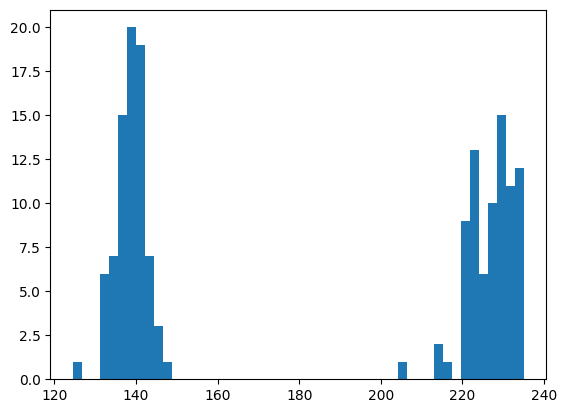

In [4]:
plt.hist([np.mean(img) for img in images_test], bins=50);

In [5]:
valid_train = [img for img in images_train if np.mean(img)>180]
unvalid_train = [img for img in images_train if np.mean(img)<180]
valid_test = [img for img in images_test if np.mean(img)>180]
unvalid_test = [img for img in images_test if np.mean(img)<180]

In [6]:
segmented_images_train = np.array([((img[:,:,0] < 180) |
                           (img[:,:,1] < 180) |
                           (img[:,:,2] < 180))
                          for img in valid_train])
segmented_images_test = np.array([((img[:,:,0] < 180) |
                          (img[:,:,1] < 180) |
                          (img[:,:,2] < 180))
                         for img in valid_test])

In [7]:
sum_train = np.sum(segmented_images_train, axis=0)
sum_test = np.sum(segmented_images_test, axis=0)

In [8]:
normalized_sum_train = (sum_train*255)/np.max(sum_train)
border_train = sum_train>0
normalized_sum_test = (sum_test*255)/np.max(sum_test)
border_test = sum_test>0

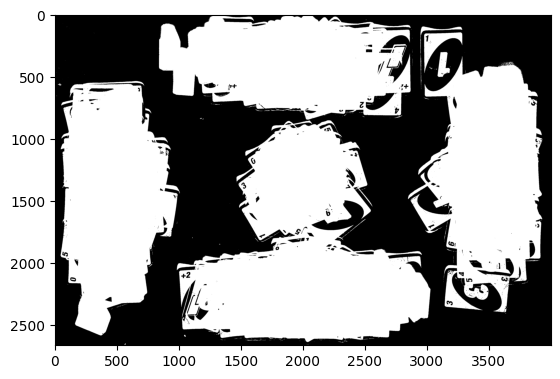

In [9]:
plt.imshow(border_test, cmap="gray")

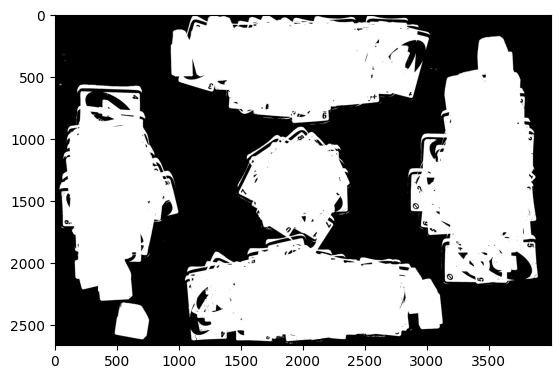

In [10]:
plt.imshow(border_train, cmap="gray")

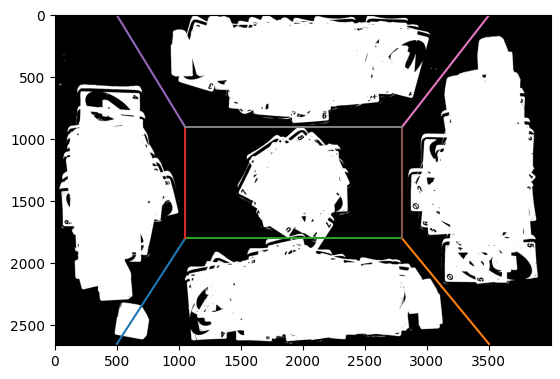

In [11]:
plt.imshow(border_train, cmap="gray")
plt.plot([500,1050],[2650,1800])
plt.plot([3500,2800],[2650,1800])
plt.plot([1050,2800], [1800,1800])
plt.plot([1050,1050],[1800,900])
plt.plot([500,1050],[0,900])
plt.plot([2800,2800],[1800,900])
plt.plot([2800,3500],[900,0])
plt.plot([1050,2800], [900,900])

In [20]:
def assign_card2player(center):

    top_l = lambda x: ((1800-2662)/(1050-500))*(x-500) + 2662
    top_r = lambda x: ((1800-2662)/(2800-3500))*(x-3500) + 2662
    bot_l = lambda x: ((900-0)/(1050-500))*(x-500)
    bot_r = lambda x: ((0-900)/(3500-2800))*(x-2800) + 900
    
    if center[1] < 900 and center[1] < bot_l(center[0]) and center[1] < bot_r(center[0]):
        return 'p3'
    if center[0] < 1050 and center[1] > bot_l(center[0]) and center[1] < top_l(center[0]):
        return 'p4'
    if center[1] > 1800 and center[1] > top_l(center[0]) and center[1] > top_r(center[0]):
        return 'p1'
    if center[0] > 2800 and center[1] > bot_r(center[0]) and center[1] < top_r(center[0]):
        return 'p2'

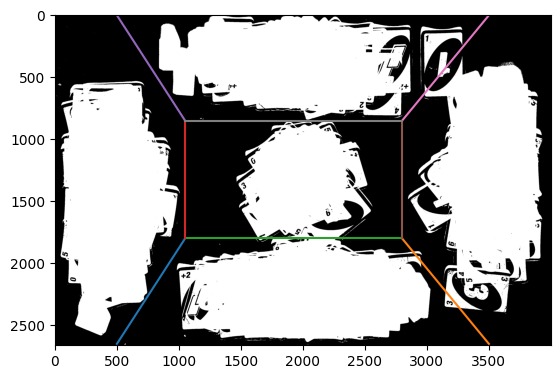

In [ ]:
plt.imshow(border_test, cmap="gray")
plt.plot([500,1050],[2650,1800])
plt.plot([3500,2800],[2650,1800])
plt.plot([1050,2800], [1800,1800])
plt.plot([1050,1050],[1800,900])
plt.plot([500,1050],[0,900])
plt.plot([2800,2800],[1800,900])
plt.plot([2800,3500],[900,0])
plt.plot([1050,2800], [900,900])

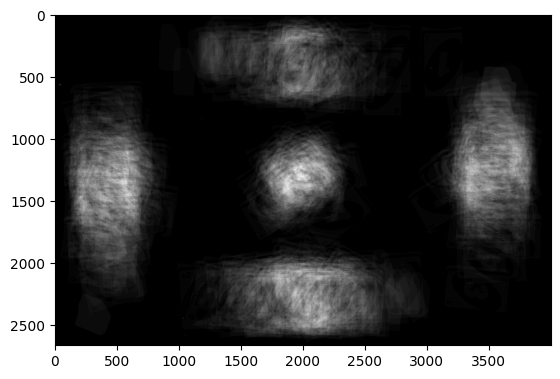

In [ ]:
plt.imshow(normalized_sum_test, cmap="gray")

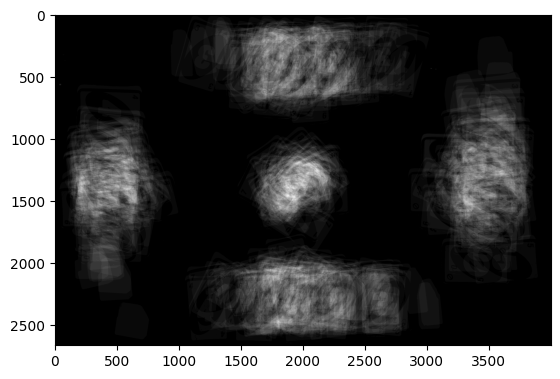

In [ ]:
plt.imshow(normalized_sum_train, cmap="gray")

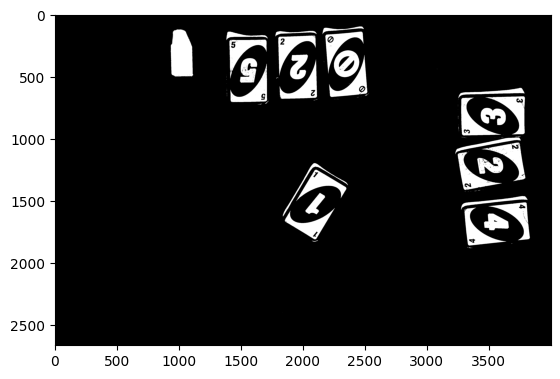

In [ ]:

plt.imshow(
    ((images_train[0][:,:,0] < 180) |
     (images_train[0][:,:,1] < 180) |
     (images_train[0][:,:,2] < 180)),
    cmap="gray"
)

In [ ]:
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects

In [ ]:
def extract_rgb_channels(img):
    """
    Extract RGB channels from the input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    data_red: np.ndarray (M, N)
        Red channel of input image
    data_green: np.ndarray (M, N)
        Green channel of input image
    data_blue: np.ndarray (M, N)
        Blue channel of input image
    """

    # Get the shape of the input image
    M, N, _ = np.shape(img)

    # Define default values for RGB channels
    data_red = np.zeros((M, N))
    data_green = np.zeros((M, N))
    data_blue = np.zeros((M, N))

    # ------------------
    data_red = img[:,:,0]
    data_green = img[:,:,1]
    data_blue = img[:,:,2]
    # ------------------
    
    return data_red, data_green, data_blue


def apply_rgb_threshold(img, r_range=(0,130), g_range=(0,100), b_range=(0,150)):
    """
    Apply threshold to input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract RGB channels
    data_red, data_green, data_blue = extract_rgb_channels(img=img)
    
    # ------------------
    img_th = (
        (r_range[0] <= data_red) & (data_red <= r_range[1]) &
        (g_range[0] <= data_green) & (data_green <= g_range[1]) &
        (b_range[0] <= data_blue) & (data_blue <= b_range[1])
    )
    # ------------------
    
    return img_th

In [ ]:
def apply_closing(img_th, disk_size):
    """
    Apply closing to input mask image using disk shape.

    Args
    ----
    img_th: np.ndarray (M, N)
        Image mask of size MxN.
    disk_size: int
        Size of the disk to use for opening

    Return
    ------
    img_closing: np.ndarray (M, N)
        Image after closing operation
    """

    # Define default value for output image
    img_closing = np.zeros_like(img_th)
    footprint = disk(disk_size)
    img_closing = closing(img_th, footprint)

    return img_closing


def apply_opening(img_th, disk_size):
    """
    Apply opening to input mask image using disk shape.

    Args
    ----
    img_th: np.ndarray (M, N)
        Image mask of size MxN.
    disk_size: int
        Size of the disk to use for opening

    Return
    ------
    img_opening: np.ndarray (M, N)
        Image after opening operation
    """

    # Define default value for output image
    img_opening = np.zeros_like(img_th)
    footprint = disk(disk_size)
    img_opening = opening(img_th, footprint)
    return img_opening

In [ ]:
def extract_hsv_channels(img):
    """
    Extract HSV channels from the input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    data_h: np.ndarray (M, N)
        Hue channel of input image
    data_s: np.ndarray (M, N)
        Saturation channel of input image
    data_v: np.ndarray (M, N)
        Value channel of input image
    """

    # Get the shape of the input image
    M, N, C = np.shape(img)

    # Define default values for HSV channels
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_v = np.zeros((M, N))

    # ------------------
    img_hsv = rgb2hsv(img)
    data_h = img_hsv[:,:,0]
    data_s = img_hsv[:,:,1]
    data_v = img_hsv[:,:,2]
    # ------------------
    
    return data_h, data_s, data_v

def apply_hsv_threshold(img, h_range=(0.6,0.8), s_range=(0.35,0.8), v_range=(0,0.6)):
    """
    Apply threshold to the input image in hsv colorspace.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.

    Return
    ------
    img_th: np.ndarray (M, N)
        Thresholded image.
    """

    # Define the default value for the input image
    M, N, C = np.shape(img)
    img_th = np.zeros((M, N))

    # Use the previous function to extract HSV channels
    data_h, data_s, data_v = extract_hsv_channels(img=img)
    
    # ------------------
    img_th = (
        (data_h < h_range[1]) &
        (data_s < s_range[1]) &
        (data_v < v_range[1]) &
        (data_h > h_range[0]) &
        (data_s > s_range[0]) &
        (data_v > v_range[0])
    )
    # ------------------
    
    return img_th

In [ ]:
def find_active_player(img):
    mean_value = img.mean()
    
    n = []

    if mean_value > 200:
        img_filter = apply_rgb_threshold(img, (0,150), (0,150), (0,150))

    else:
        print('l')
        img_filter = apply_rgb_threshold(img, (200,255), (200,255), (0,80))

    img_1 = apply_opening(img_filter[1900:,500:3500], 20)
    img_2 = apply_opening(img_filter[:,3100:], 20)
    img_3 = apply_opening(img_filter[:900,500:3500], 20)
    img_4 = apply_opening(img_filter[:,:750], 20)

    n.append(sum(img_1[img_1 == True]))
    n.append(sum(img_2[img_2 == True]))
    n.append(sum(img_3[img_3 == True]))
    n.append(sum(img_4[img_4 == True]))

    player = np.argmax(n) + 1
    plt.imshow(img)
    plt.show()
    plt.imshow(img_filter)

    return "p"+str(player)

l


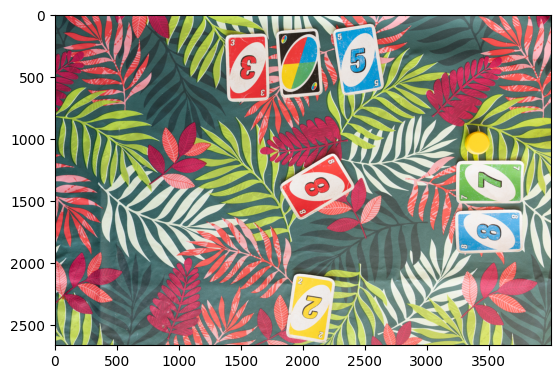

'p2'

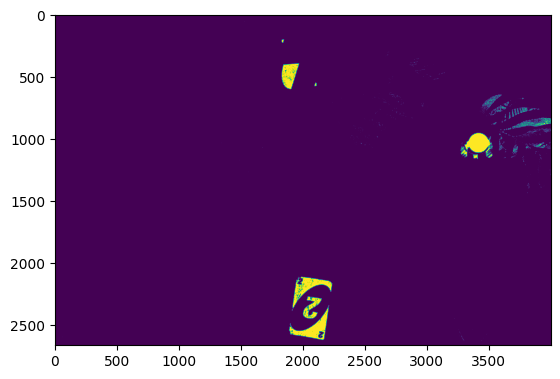

In [ ]:
find_active_player(cv2.cvtColor(unvalid_train[0], cv2.COLOR_BGR2RGB))

In [ ]:
img = unvalid_train[1]

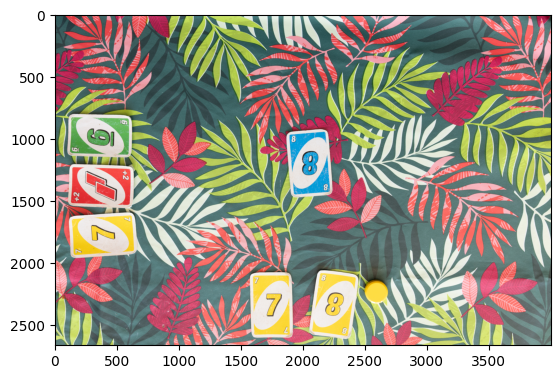

In [ ]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [ ]:
def card_only_filter_blank(img):
    return ((img[:,:,0] < 180) |
            (img[:,:,1] < 180) |
            (img[:,:,2] < 180))
    
def card_only_filter_leaf(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_filtered = apply_rgb_threshold(rgb, r_range=(190,255), g_range=(190,255), b_range=(190,255))
    hsv_filtered = (hsv[:,:,0]<30) | ((hsv[:,:,0]<170)&(hsv[:,:,0]>160))
    return rgb_filtered & hsv_filtered

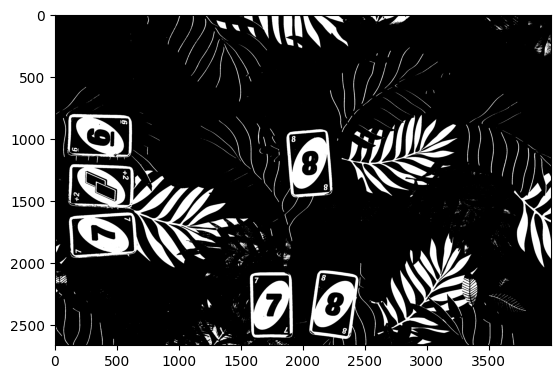

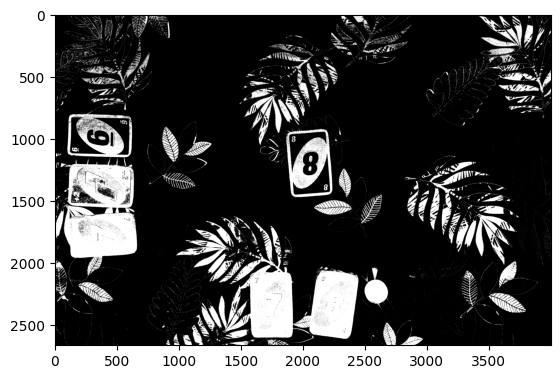

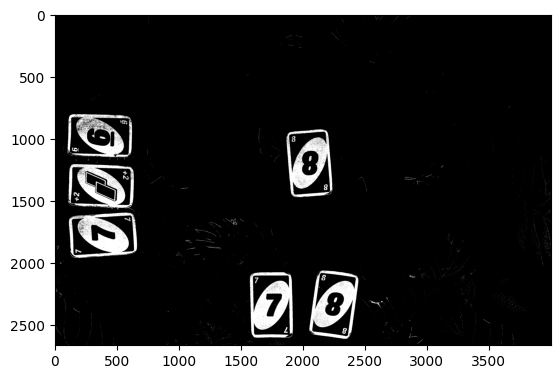

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rgb_filtered = apply_rgb_threshold(rgb, r_range=(190,255), g_range=(190,255), b_range=(190,255))
hsv_filtered = (hsv[:,:,0]<30) | ((hsv[:,:,0]<170)&(hsv[:,:,0]>160))
plt.imshow(rgb_filtered, cmap='gray')
plt.show()
plt.imshow(hsv_filtered.astype(np.uint8), cmap='gray')
plt.show()
plt.imshow(rgb_filtered & hsv_filtered, cmap='gray')


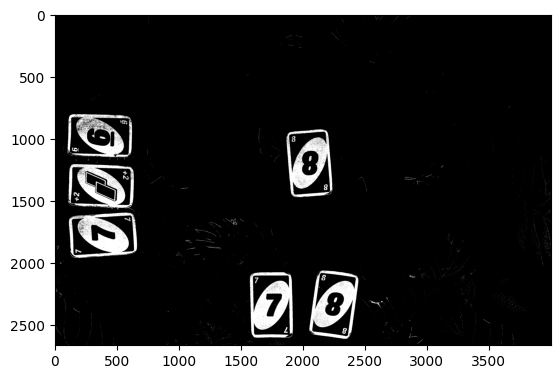

In [ ]:
segmented_img = card_only_filter_leaf(img)
plt.imshow(segmented_img, cmap='gray')

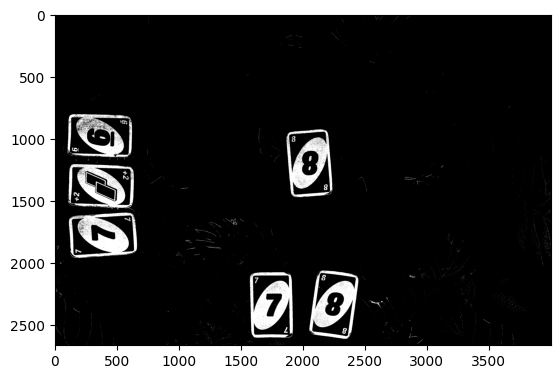

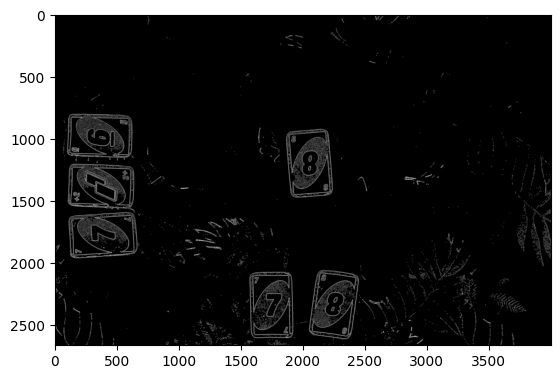

In [ ]:
segmented_img = card_only_filter_leaf(img)
plt.imshow(segmented_img, cmap='gray')
plt.show() 

segmented_img[segmented_img == 1] = 255
segmented_img = segmented_img.astype(np.uint8)

sobelx = cv2.Sobel(segmented_img, cv2.CV_64F, 1, 0)
sobely = cv2.Sobel(segmented_img, cv2.CV_64F, 0, 1)

magnitude = np.sqrt(sobelx**2 + sobely**2)

for i in range(2):

    sobelx = cv2.Sobel(magnitude, cv2.CV_64F, 1, 0)
    sobely = cv2.Sobel(magnitude, cv2.CV_64F, 0, 1)

    magnitude = np.sqrt(sobelx**2 + sobely**2)
    
plt.imshow(magnitude, cmap="gray")
plt.show()

In [ ]:
magnitude[magnitude == 1] = 255
magnitude = magnitude.astype(np.uint8)

In [ ]:
def detect_card_contours(img, min_area=100000, max_area=250000):
    """
    Args:
        img: Input RGB image
        min_area: Minimum contour area (filter out noise)
        max_area: Maximum contour area (filter out large regions)
        
    Returns:
        List of valid card contours and the edge map
    """
    # Convert to grayscale for edge detection
    #gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # Canny edge detection
    edges = cv2.Canny(img, 50, 150)
    
    # Apply dilation to connect nearby edges
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (4, 4))
    dilated = cv2.dilate(edges, kernel, iterations=2)
    
    # Find contours
    contours, _ = cv2.findContours(dilated, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on area and shape
    valid_contours = []
    for contour in contours:
        area = cv2.contourArea(contour)
        
        # Filter by area
        if area < min_area or area > max_area:
            continue
        
        # Get the convex hull
        hull = cv2.convexHull(contour)
        hull_area = cv2.contourArea(hull)
        
        # Calculate solidity
        if hull_area > 0:
            solidity = float(area) / hull_area
            if solidity < 0.6: 
                continue
        
        # Get bounding rect and check aspect ratio
        x, y, w, h = cv2.boundingRect(contour)
        if w == 0 or h == 0:
            continue
        
        aspect_ratio = float(w) / h
        # Uno cards have aspect ratio around 0.6-1.6 
        if aspect_ratio < 0.4 or aspect_ratio > 2.0:
            continue
        
        # Approximate contour to polygon
        epsilon = 0.02 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)
        
        # Cards should have at least 4 corners
        if len(approx) >= 4:
            valid_contours.append(contour)
    
    return valid_contours, edges, dilated

In [ ]:
valid_contours, edges, dilated = detect_card_contours(magnitude)

In [ ]:
normalized_cards = []
for contour in valid_contours:
    normalized_cards.append(extract_and_normalize_card(img,contour))

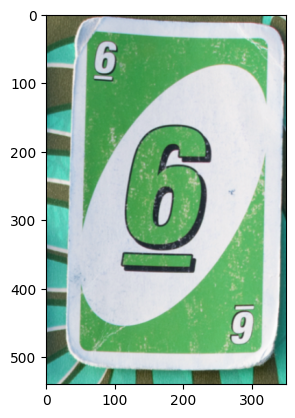

In [ ]:
plt.imshow(normalized_cards[5][0])